In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--dataset_id', 'kind-detuning-filter',
        '--file_dir', '../../data/kalman',
        '--file_name', 'tesla_sim',
        '--data_nsample', '500',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--nepoch', '100',
        '--patience', '10',
        '--checkpoints', '../../models/kalman/filter',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 3, "cos": 3}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '64',
        '--nlayer_stat', '2',
    ]
)

In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.549613, valid=0.139880, test=0.123590
	validation loss decreased (inf -> 0.139880), saving model ...
	epoch 2 losses: train=0.744043, valid=0.072388, test=0.072291
	validation loss decreased (0.139880 -> 0.072388), saving model ...
	epoch 3 losses: train=0.691247, valid=0.067380, test=0.066431
	validation loss decreased (0.072388 -> 0.067380), saving model ...
	epoch 4 losses: train=0.666706, valid=0.066367, test=0.065872
	validation loss decreased (0.067380 -> 0.066367), saving model ...
	epoch 5 losses: train=0.613961, valid=0.076014, test=0.072209
	early stopping counter: 1 out of 10
	epoch 6 losses: train=0.379418, valid=0.036016, test=0.038015
	validation loss decreased (0.066367 -> 0.036016), saving model ...
	epoch 7 losses: train=0.263452, valid=0.025719, test=0.028233
	validation loss decreased (0.036016 -> 0.025719), saving model ...
	epoch 8 losses: train=0.244244, valid=0.022193, test=0.024529
	validation loss decreased

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

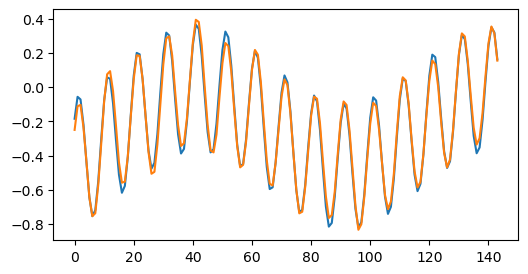

In [6]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break